#  Financial Personality Segmentation & Spending Intelligence System

## Objective
This project analyzes customer financial behavior using:
- SQL database
- Data analysis (Pandas, NumPy)
- Visualization (Matplotlib)
- Clustering (K-Means)
- Regression & Classification (Scikit-learn)

Goal:
- Segment users into financial personalities
- Predict spending behavior
- Classify financial risk levels

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, mean_absolute_error

print("Libraries Imported Successfully ✅")

Libraries Imported Successfully ✅


In [3]:
# Create database connection
conn = sqlite3.connect("finance.db")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS transactions (
    User_ID INTEGER,
    Age INTEGER,
    Income REAL,
    Monthly_Expenses REAL,
    Savings REAL,
    Credit_Score INTEGER,
    Transaction_Amount REAL,
    Category TEXT,
    Date TEXT
)
""")

conn.commit()
print("Database Created Successfully ✅")

Database Created Successfully ✅


In [4]:
## Generate Synthetic Dataset


np.random.seed(42)

data = {
    "User_ID": np.arange(1,201),
    "Age": np.random.randint(21,60,200),
    "Income": np.random.randint(20000,150000,200),
    "Monthly_Expenses": np.random.randint(10000,100000,200),
    "Savings": np.random.randint(5000,50000,200),
    "Credit_Score": np.random.randint(500,850,200),
    "Transaction_Amount": np.random.randint(500,20000,200),
    "Category": np.random.choice(["Food","Travel","Shopping","EMI","Bills"],200),
    "Date": pd.date_range(start="2024-01-01", periods=200)
}

df = pd.DataFrame(data)
df.head()

,User_ID,Age,Income,Monthly_Expenses,Savings,Credit_Score,Transaction_Amount,Category,Date
0,1,59,69811,15801,37307,750,9833,Bills,2024-01-01
1,2,49,22811,29190,10486,812,17108,Shopping,2024-01-02
2,3,35,76250,59689,13335,611,13319,Shopping,2024-01-03
3,4,28,132547,60993,26364,754,4708,Shopping,2024-01-04
4,5,41,92082,39592,42259,802,6783,Bills,2024-01-05


In [5]:
## Insert Data into SQL

df.to_sql("transactions", conn, if_exists="replace", index=False)
print("Data inserted into SQL successfully ✅")

Data inserted into SQL successfully ✅


In [6]:
## Load Data from SQL

df = pd.read_sql_query("SELECT * FROM transactions", conn)
df.head()

,User_ID,Age,Income,Monthly_Expenses,Savings,Credit_Score,Transaction_Amount,Category,Date
0,1,59,69811,15801,37307,750,9833,Bills,2024-01-01 00:00:00
1,2,49,22811,29190,10486,812,17108,Shopping,2024-01-02 00:00:00
2,3,35,76250,59689,13335,611,13319,Shopping,2024-01-03 00:00:00
3,4,28,132547,60993,26364,754,4708,Shopping,2024-01-04 00:00:00
4,5,41,92082,39592,42259,802,6783,Bills,2024-01-05 00:00:00


In [7]:
## Feature Engineering


df["Savings_Ratio"] = df["Savings"] / df["Income"]
df["Expense_Ratio"] = df["Monthly_Expenses"] / df["Income"]

df["Risk_Score"] = (
    (df["Expense_Ratio"] * 0.6) +
    ((700 - df["Credit_Score"]) / 700 * 0.4)
)

df.head()

,User_ID,Age,Income,Monthly_Expenses,Savings,Credit_Score,Transaction_Amount,Category,Date,Savings_Ratio,Expense_Ratio,Risk_Score
0,1,59,69811,15801,37307,750,9833,Bills,2024-01-01 00:00:00,0.534400,0.226340,0.107232
1,2,49,22811,29190,10486,812,17108,Shopping,2024-01-02 00:00:00,0.459691,1.279646,0.703787
2,3,35,76250,59689,13335,611,13319,Shopping,2024-01-03 00:00:00,0.174885,0.782807,0.520541
3,4,28,132547,60993,26364,754,4708,Shopping,2024-01-04 00:00:00,0.198903,0.460161,0.245240
4,5,41,92082,39592,42259,802,6783,Bills,2024-01-05 00:00:00,0.458928,0.429965,0.199693


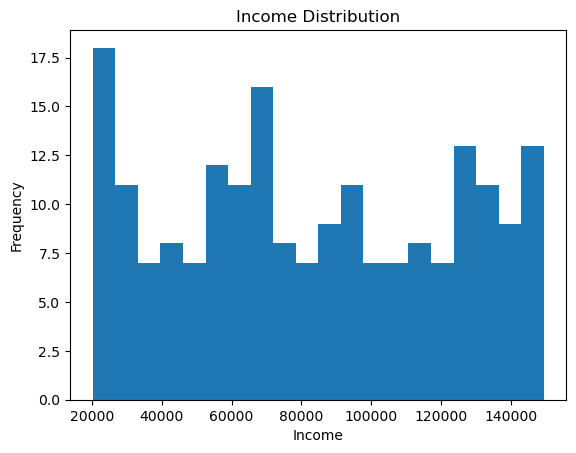

In [8]:
## Basic EDA
## Income Distribution



plt.hist(df["Income"], bins=20)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

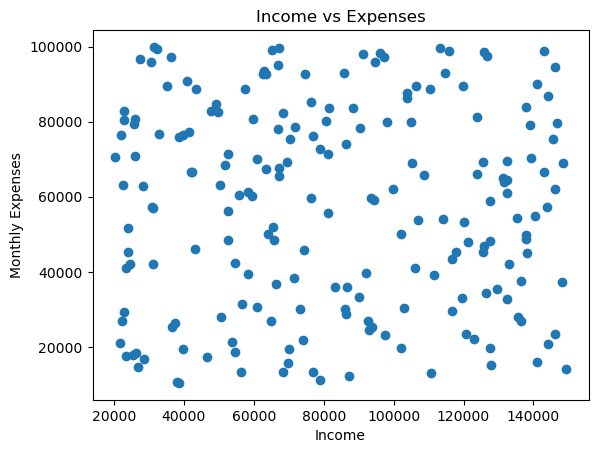

In [9]:
## Income vs Expenses



plt.scatter(df["Income"], df["Monthly_Expenses"])
plt.xlabel("Income")
plt.ylabel("Monthly Expenses")
plt.title("Income vs Expenses")
plt.show()

In [10]:
## Financial Personality Segmentation (Clustering) 
## Scale Data





features = df[["Income","Expense_Ratio","Savings_Ratio","Credit_Score"]]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [11]:
## Apply KMeans




kmeans = KMeans(n_clusters=4, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled_features)

df["Cluster"].value_counts()

C:\Users\chait\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Cluster
3    66
1    66
2    49
0    19
Name: count, dtype: int64

In [12]:
## Label Personalities




cluster_labels = {
    0: "Smart Saver",
    1: "Risky Spender",
    2: "Stable Planner",
    3: "Luxury Lifestyle"
}

df["Personality"] = df["Cluster"].map(cluster_labels)

df[["User_ID","Personality"]].head()

,User_ID,Personality
0,1,Luxury Lifestyle
1,2,Stable Planner
2,3,Risky Spender
3,4,Luxury Lifestyle
4,5,Luxury Lifestyle


In [13]:
## Spending Prediction (Regression)





X = df[["Income","Savings_Ratio","Expense_Ratio","Credit_Score"]]
y = df["Monthly_Expenses"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

reg_model = RandomForestRegressor()
reg_model.fit(X_train,y_train)

y_pred = reg_model.predict(X_test)

print("R2 Score:", r2_score(y_test,y_pred))
print("MAE:", mean_absolute_error(y_test,y_pred))

R2 Score: 0.9602218125484486
MAE: 4045.4252500000002


In [14]:
## Risk Classification


df["Risk_Level"] = np.where(df["Risk_Score"] > 0.6, "High",
                     np.where(df["Risk_Score"] > 0.4, "Moderate", "Low"))

X_class = df[["Income","Expense_Ratio","Credit_Score"]]
y_class = df["Risk_Level"]

X_train, X_test, y_train, y_test = train_test_split(X_class,y_class,test_size=0.2)

clf = RandomForestClassifier()
clf.fit(X_train,y_train)

print("Classification Model Trained ✅")

Classification Model Trained ✅


In [15]:
## Store Insights Back to SQL



cursor.execute("""
CREATE TABLE IF NOT EXISTS user_insights (
    User_ID INTEGER,
    Personality TEXT,
    Risk_Level TEXT
)
""")

insights = df[["User_ID","Personality","Risk_Level"]]
insights.to_sql("user_insights", conn, if_exists="replace", index=False)

print("Insights stored in SQL ✅")

Insights stored in SQL ✅


##  Time Series Analysis: Monthly Spending Trend

Objective:
Analyze how total spending changes over time.

In [16]:
df["Date"] = pd.to_datetime(df["Date"])

In [17]:
monthly_spending = df.groupby(df["Date"].dt.month)["Transaction_Amount"].sum()

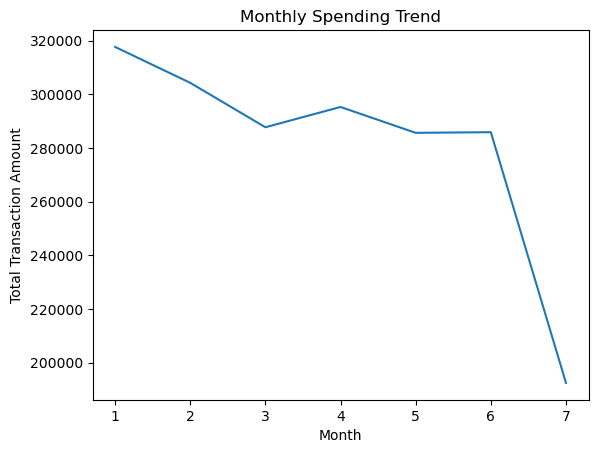

In [18]:
plt.figure()
plt.plot(monthly_spending.index, monthly_spending.values)
plt.xlabel("Month")
plt.ylabel("Total Transaction Amount")
plt.title("Monthly Spending Trend")
plt.show()

##  Principal Component Analysis (PCA)

Objective:
Reduce dimensionality and visualize financial behavior clusters.

In [19]:
from sklearn.decomposition import PCA

In [20]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_features)

df["PCA1"] = pca_components[:,0]
df["PCA2"] = pca_components[:,1]

## </h3>Plot PCA clusters:</h3> 

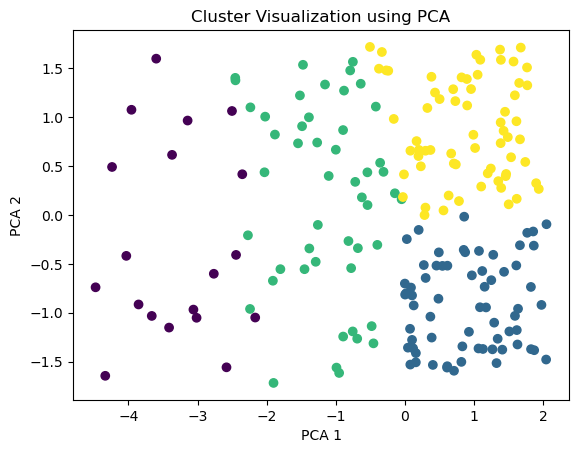

In [29]:
plt.figure()
plt.scatter(df["PCA1"], df["PCA2"], c=df["Cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Cluster Visualization using PCA")
plt.show()

## Silhouette Score (Cluster Validation)

This proves clustering quality

In [22]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_features, df["Cluster"])
print("Silhouette Score:", score)

Silhouette Score: 0.3014274265828139


## Interpretation:

0.5 → Strong clusters

0.3–0.5 → Moderate

< 0.3 → Weak

## Dashboard Visualization

## Cluster Distribution

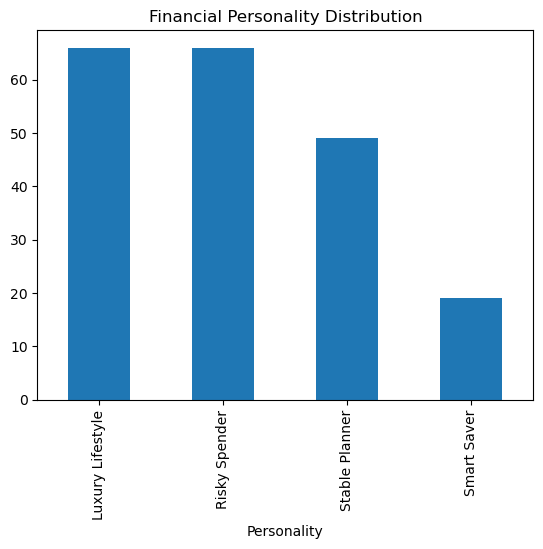

In [23]:
df["Personality"].value_counts().plot(kind="bar")
plt.title("Financial Personality Distribution")
plt.show()

## Risk Level Distribution

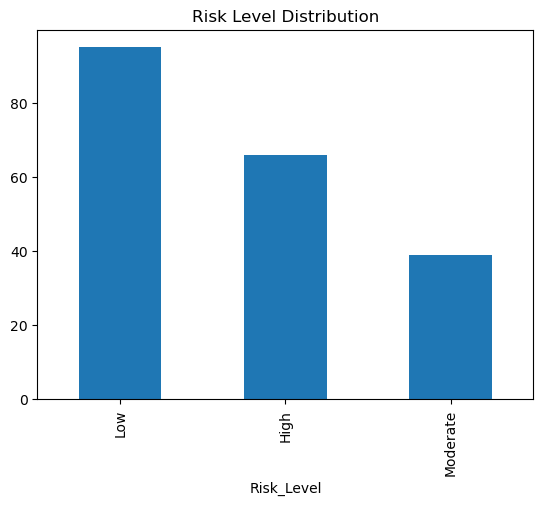

In [24]:
df["Risk_Level"].value_counts().plot(kind="bar")
plt.title("Risk Level Distribution")
plt.show()

## Average Income per Personality

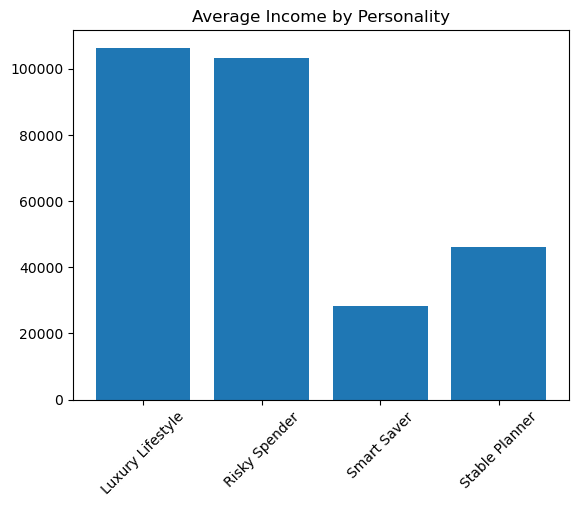

In [25]:
avg_income = df.groupby("Personality")["Income"].mean()

plt.figure()
plt.bar(avg_income.index, avg_income.values)
plt.xticks(rotation=45)
plt.title("Average Income by Personality")
plt.show()